Question 1:<br>
Variables:<br>
V(H, P, D) where: <br>
H ∈ {H1, ..., H14}<br>
P ∈ {P1, P2, P3, P4}<br>
D ∈ {Sunday, Monday, Tuesday, Wednesday, Thursday}<br>
Each variable represents the assignment of a proctor R to a specific hall H in period P of day D<br>
Total number of variables: 14 halls * 4 periods * 5 days = 280 variables<br>
Domains:<br>
D(V) = {R1, R2, ..., R30}<br>
Constraints:<br>
1. V(H, D, P) ∈ AvailableProctors(D)
2. Count (V(H, D, P) = Ri) ≤ 3  for all P and H on day D
3. V(H1, D1, P1) ≠ V(H2, D2, P2)  for all H1 ≠ H2, D1 = D2, P1 = P2
4. H1 ≠ H2  for all V(H1, D1, P1) = V(H2, D2, P2), P1 ≠ P2, D1 = D2
5. ∀ H, D, P,  Ǝ V(H, D, P)

Note: Unary Constraint C1 (Work Days) is implicit in the domain of each node.


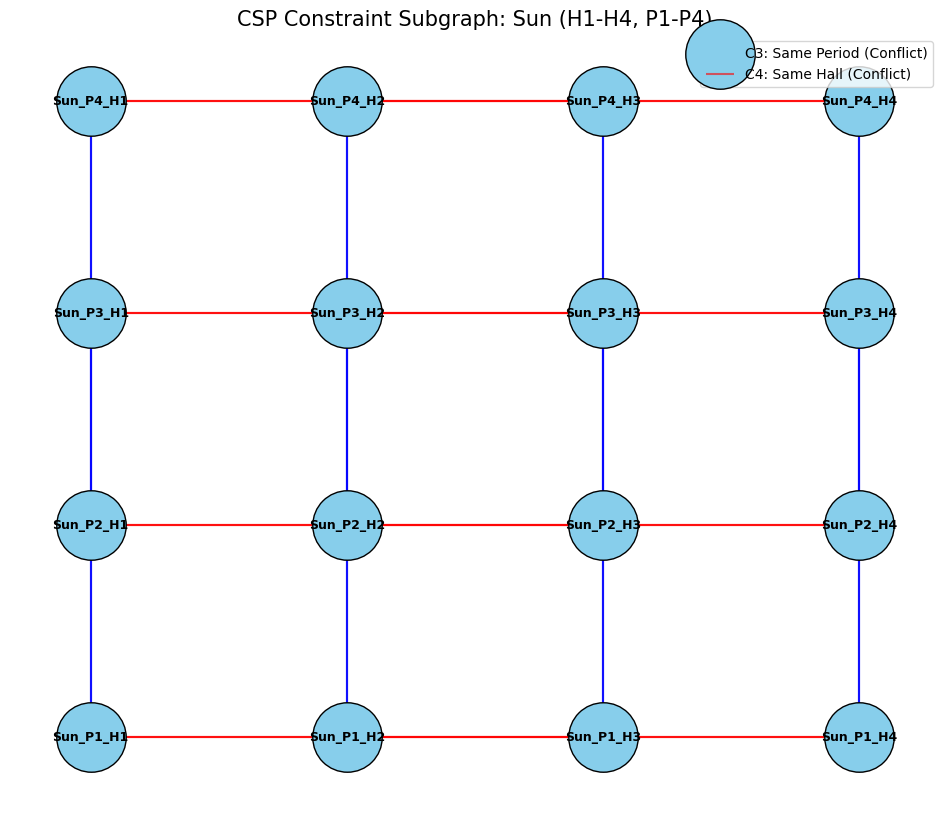

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# Initialize the graph
G = nx.Graph()

# Setup parameters
day = "Sun"
periods = ["P1", "P2", "P3", "P4"]
halls = ["H1", "H2", "H3", "H4"]

# 1. Define Nodes (Variables) 
# Each node represents a (Day, Period, Hall) slot
nodes = [f"{day}_{p}_{h}" for p in periods for h in halls]
G.add_nodes_from(nodes)

# 2. Define Edges (Constraints) [cite: 13]
for p in periods:
    for h in halls:
        current_node = f"{day}_{p}_{h}"
        
        # Constraint C3: No Time Overlap 
        # A proctor cannot be in two halls at the same time
        for other_h in halls:
            if h != other_h:
                G.add_edge(current_node, f"{day}_{p}_{other_h}", label='C3')
        
        # Constraint C4: Different Halls 
        # A proctor cannot monitor the same hall twice in one day
        for other_p in periods:
            if p != other_p:
                G.add_edge(current_node, f"{day}_{other_p}_{h}", label='C4')

# 3. Plotting
plt.figure(figsize=(12, 10))

# Position nodes in a grid for readability
pos = {f"{day}_{p}_{h}": (i, j) for j, p in enumerate(periods) for i, h in enumerate(halls)}

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=2500, node_color='skyblue', edgecolors='black')
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

# Draw edges with different styles for C3 and C4
c3_edges = [(u, v) for u, v, d in G.edges(data=True) if d['label'] == 'C3']
c4_edges = [(u, v) for u, v, d in G.edges(data=True) if d['label'] == 'C4']

nx.draw_networkx_edges(G, pos, edgelist=c3_edges, edge_color='red', width=1.5, alpha=0.6, label='C3: Time Conflict')
nx.draw_networkx_edges(G, pos, edgelist=c4_edges, edge_color='blue', width=1.5, alpha=0.6, label='C4: Hall Conflict')

# Add a legend and title
plt.title(f"CSP Constraint Subgraph: {day} (H1-H4, P1-P4)", fontsize=15)
plt.legend(['C3: Same Period (Conflict)', 'C4: Same Hall (Conflict)'], loc='upper right', scatterpoints=1)
plt.axis('off')

# Note on Unary Constraints (C1) 
print("Note: Unary Constraint C1 (Work Days) is implicit in the domain of each node.")

plt.show()